<a href="https://colab.research.google.com/github/tharindu9216/Accident-Severity-Classifier-/blob/Cascade_Random_Forest/Cascade_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cascade Random Forest — Road Accident Severity Prediction

---

## 1. Dataset Selection & Justification

**Dataset:** Road Accident Casualties Dataset  
**Source:** [https://www.kaggle.com/datasets/nezukokamaado/road-accident-casualties-dataset](https://www.kaggle.com/datasets/nezukokamaado/road-accident-casualties-dataset)  
**Author:** nezukokamaado on Kaggle  

### Why this dataset is appropriate

This dataset was selected because it satisfies all required criteria for a supervised machine learning assignment:

- **Real-world, non-tutorial data:** The dataset contains genuine UK road accident records collected by the Department for Transport. It is not associated with any textbook example or ML tutorial.
- **Complexity:** With 307,973 records and 21 features spanning categorical, numerical, and temporal attributes, the dataset presents realistic challenges including class imbalance, missing values, and heterogeneous feature types.
- **Publicly hosted:** The dataset is permanently hosted on Kaggle with a citable URL, satisfying the requirement that data be accessible online.

### Dataset description

| Property | Detail |
|---|---|
| Records | 307,973 road accidents |
| Features | 21 columns (17 categorical, 4 numerical) |
| Target variable | `Accident_Severity` — Fatal / Serious / Slight |
| Year coverage | 2021 (UK national data) |
| Class distribution | ~85% Slight, ~14% Serious, ~1% Fatal (imbalanced) |
| Missing values | Present in `Carriageway_Hazards`, `Junction_Control` |

**Key features include:** Day of week, road type, speed limit, light conditions, weather conditions, road surface conditions, urban/rural classification, vehicle type, junction control, and number of casualties/vehicles.

**Prediction task:** Multi-class classification — given the conditions of a road accident, predict whether the outcome is *Fatal*, *Serious*, or *Slight*. This is a high-value real-world problem: accurate severity prediction can inform emergency response prioritisation and road safety policy.

---

## 2. Algorithm Selection & Justification

**Algorithm:** Cascade Random Forest (gcForest-inspired, Zhou & Feng, 2017)

### Why Cascade Random Forest

| Criterion | Justification |
|---|---|
| Non-linearity | Road accident severity is determined by complex, non-linear interactions between features (e.g., high speed + poor weather + night-time = higher fatal risk). Linear models cannot capture these. |
| Handles categorical data | After One-Hot Encoding, the feature space is large and sparse. Random Forests handle this natively without requiring feature selection. |
| No scaling required | Unlike Logistic Regression or SVM, Random Forests do not require StandardScaler — reducing preprocessing complexity and risk of data leakage. |
| Cascade advantage over single RF | Each cascade stage receives the probability outputs of the previous stage as additional features. This allows later stages to learn from the uncertainty of earlier stages, improving detection of ambiguous cases (e.g., Serious vs Fatal). This is the key innovation over a standard Random Forest. |
| Interpretability | Feature importance scores from each stage provide actionable insight into which road conditions most influence accident severity. |

### Algorithm background

The Cascade Random Forest is inspired by the **Deep Forest (gcForest)** architecture proposed by Zhou & Feng (2017) in *"Deep Forest: Towards an Alternative to Deep Neural Networks"*. Unlike neural networks, which achieve depth through stacked weight layers, gcForest achieves depth by stacking tree ensembles where each stage's **class probability vector** is appended to the input features for the next stage.

**Three-stage cascade used in this implementation:**
- **Stage 1:** Random Forest trained on preprocessed features → outputs P(Fatal), P(Serious), P(Slight)
- **Stage 2:** Random Forest trained on [original features + Stage 1 probabilities] → corrects Stage 1 errors
- **Stage 3:** Random Forest trained on [Stage 2 features + Stage 2 probabilities] → final prediction

**Reference:** Zhou, Z.-H., & Feng, J. (2017). Deep Forest: Towards an Alternative to Deep Neural Networks. *arXiv:1702.08835*.

---

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install gdown -q
import gdown

# Download from the shared Google Drive link
file_id = '1qlq6_GgAZRACXnxjuqVoSZJdoZ_WBnrX'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'Road_Accident_Data.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1qlq6_GgAZRACXnxjuqVoSZJdoZ_WBnrX
To: /content/Road_Accident_Data.csv
100%|██████████| 69.0M/69.0M [00:00<00:00, 85.6MB/s]


'Road_Accident_Data.csv'

In [5]:
# To Check Data Was Succefully Downloaded.
import pandas as pd

# Load the CSV file
df = pd.read_csv("Road_Accident_Data.csv")

# Display the first 5 rows
print(df.head())


  Accident_Index Accident Date Day_of_Week          Junction_Control  \
0      BS0000001      1/1/2021    Thursday  Give way or uncontrolled   
1      BS0000002      5/1/2021      Monday  Give way or uncontrolled   
2      BS0000003      4/1/2021      Sunday  Give way or uncontrolled   
3      BS0000004      5/1/2021      Monday       Auto traffic signal   
4      BS0000005      6/1/2021     Tuesday       Auto traffic signal   

           Junction_Detail Accident_Severity   Latitude  \
0  T or staggered junction           Serious  51.512273   
1               Crossroads           Serious  51.514399   
2  T or staggered junction            Slight  51.486668   
3  T or staggered junction           Serious  51.507804   
4               Crossroads           Serious  51.482076   

        Light_Conditions Local_Authority_(District) Carriageway_Hazards  ...  \
0               Daylight     Kensington and Chelsea                 NaN  ...   
1               Daylight     Kensington and Chelsea 

In [6]:
# Load & Inspect the Data
import pandas as pd
import numpy as np

df = pd.read_csv('Road_Accident_Data.csv')
print(df.shape)           # (307973, 21)
print(df.dtypes)          # shows column types
print(df.isnull().sum())  # shows missing values per column
print(df['Accident_Severity'].value_counts())  # class distribution

(307973, 21)
Accident_Index                 object
Accident Date                  object
Day_of_Week                    object
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Carriageway_Hazards            object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object
dtype: object
Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail            

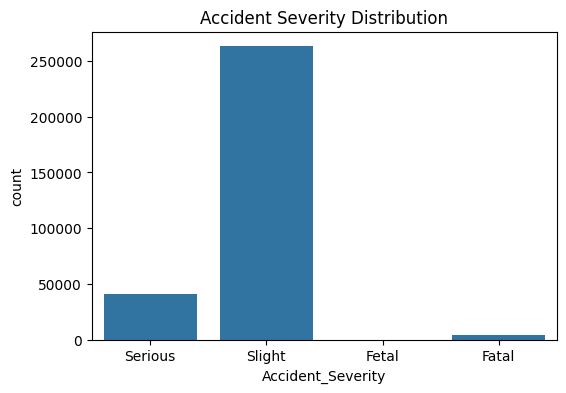

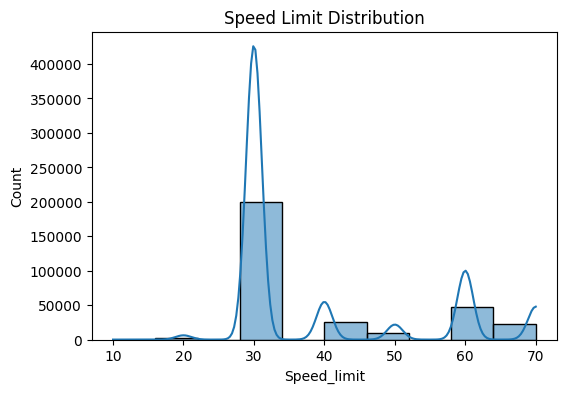

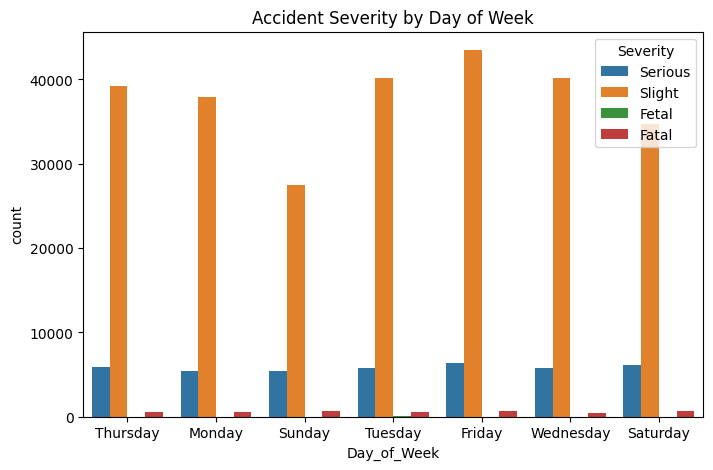

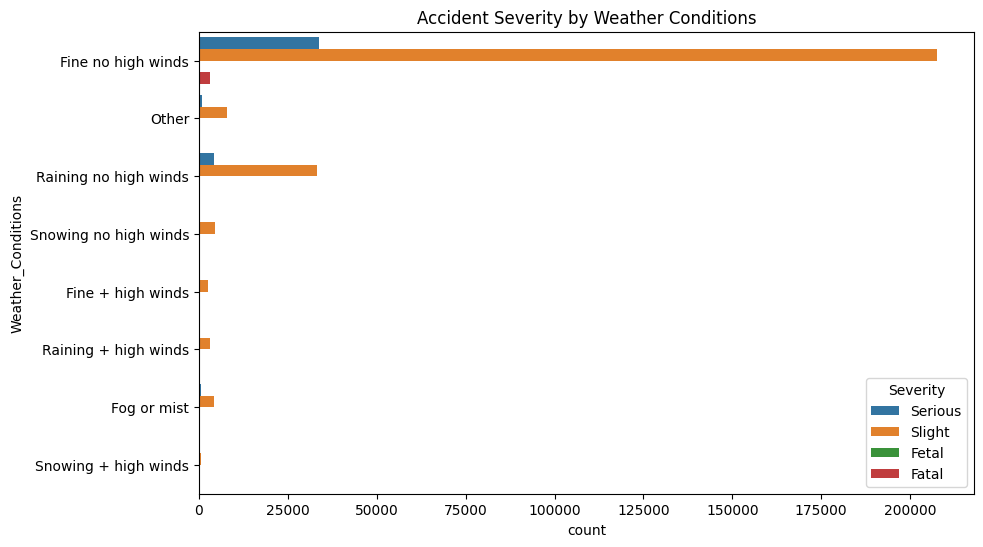

In [7]:
# plots and charts for data-set

import matplotlib.pyplot as plt
import seaborn as sns

# Accident Severity Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Accident_Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()
print()

# Speed Limit Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Speed_limit'], bins=10, kde=True)
plt.title("Speed Limit Distribution")
plt.show()
print()

# Day of Week vs Severity
plt.figure(figsize=(8,5))
sns.countplot(x='Day_of_Week', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Day of Week")
plt.legend(title="Severity")
plt.show()
print()

# Weather Conditions vs Severity
plt.figure(figsize=(10,6))
sns.countplot(y='Weather_Conditions', hue='Accident_Severity', data=df)
plt.title("Accident Severity by Weather Conditions")
plt.legend(title="Severity")
plt.show()

In [8]:
# Drop Irrelevant Columns
df = df.drop(columns=['Accident_Index', 'Latitude', 'Longitude',
                       'Local_Authority_(District)', 'Police_Force'])

In [9]:
# Handle Missing Values
from sklearn.impute import SimpleImputer

#Feature Engineering
# Create High_Speed feature: 1 if speed limit >= 60, else 0
df['High_Speed'] = (df['Speed_limit'] >= 60).astype(int)

In [10]:
# Encode Target Variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Accident_Severity'] = le.fit_transform(df['Accident_Severity'])
# Slight=2, Serious=1, Fatal=0  (alphabetical order)
print('Classes:', le.classes_)

Classes: ['Fatal' 'Fetal' 'Serious' 'Slight']


In [11]:
# Separate Features (X) and Target (y)
# Define the target column
TARGET = 'Accident_Severity'

# Columns to drop from features
DROP_COLS = ['Accident_Index', 'Accident Date', 'Latitude', 'Longitude',
             'Local_Authority_(District)', 'Police_Force', 'Time']

X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])
y = df[TARGET]
print('Feature shape:', X.shape)

Feature shape: (307973, 14)


In [12]:
# Train/Test Split (80/20, stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # reproducibility seed
    stratify=y           # keep class proportions in both splits
)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (246378, 14) | Test: (61595, 14)


In [13]:
# Build Preprocessing Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Pipeline for categorical columns
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# Pipeline for numerical columns (tree model version — NO scaling)
num_pipe_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# ColumnTransformer applies each pipeline to the right columns
preproc_tree = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('num', num_pipe_tree, num_cols)
])

# FIT on training data ONLY — then transform both train and test
preproc_tree.fit(X_train)
Xtr_tree = preproc_tree.transform(X_train)
Xte_tree = preproc_tree.transform(X_test)

# Convert sparse matrix to dense for SMOTE compatibility
Xtr_tree_dense = Xtr_tree.toarray() if hasattr(Xtr_tree, 'toarray') else Xtr_tree
Xte_tree_dense = Xte_tree.toarray() if hasattr(Xte_tree, 'toarray') else Xte_tree


In [14]:
# Handle Class Imbalance with SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Before SMOTE:', Counter(y_train))

sm = SMOTE(random_state=42)
Xtr_res, ytr_res = sm.fit_resample(Xtr_tree_dense, y_train)

print('After SMOTE:', Counter(ytr_res))



Before SMOTE: Counter({3: 210624, 2: 32592, 0: 3123, 1: 39})
After SMOTE: Counter({3: 210624, 0: 210624, 2: 210624, 1: 210624})


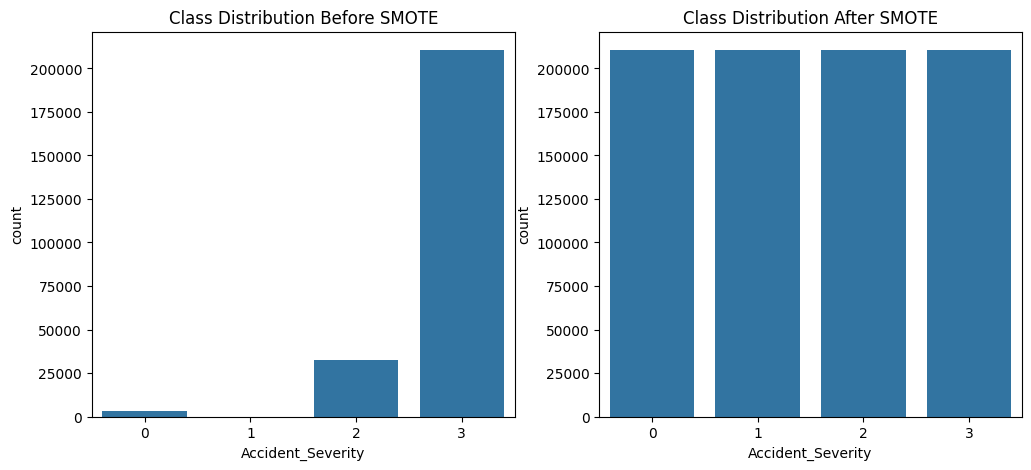

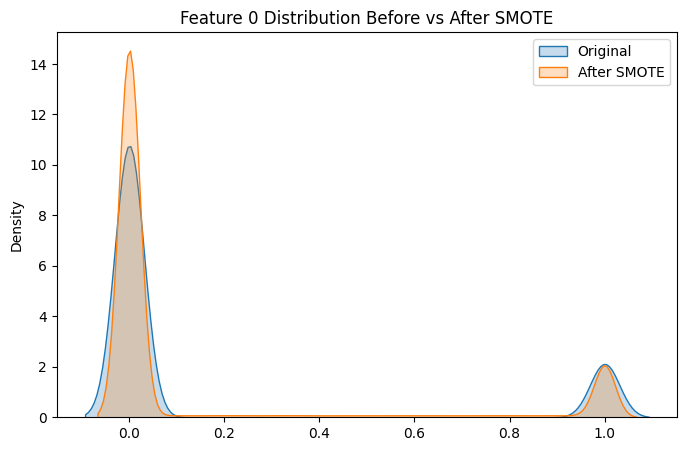

In [15]:
# Plots for handling imbalance before and after.
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Plot class distribution before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Class Distribution Before SMOTE")

# After SMOTE
sns.countplot(x=ytr_res, ax=axes[1])
axes[1].set_title("Class Distribution After SMOTE")

plt.show()
print()

# Optional: Compare feature distributions before vs after SMOTE
feature = 0  # pick a feature index (e.g., 0 for first column)
plt.figure(figsize=(8,5))
sns.kdeplot(Xtr_tree_dense[:, feature], label="Original", fill=True)
sns.kdeplot(Xtr_res[:, feature], label="After SMOTE", fill=True)
plt.title(f"Feature {feature} Distribution Before vs After SMOTE")
plt.legend()
plt.show()

In [16]:
# CASCADE RANDOM FOREST IMPLEMENTATION
# Algorithm: gcForest-inspired cascade (Zhou & Feng, 2017)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score, roc_auc_score
)

# Evaluation helper function
def evaluate(y_true, y_pred, y_proba=None, title=''):
    print('\n' + '='*50)
    print(f' {title}')
    print('='*50)
    print('Accuracy:         ', round(accuracy_score(y_true, y_pred), 4))
    print('Macro F1-score:   ', round(f1_score(y_true, y_pred, average='macro'), 4))
    print('Balanced Accuracy:', round(balanced_accuracy_score(y_true, y_pred), 4))

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        print('ROC-AUC (macro):  ', round(auc, 4))

    print()
    print(classification_report(
        y_true, y_pred,
        target_names=['Fatal', 'Fetal', 'Serious', 'Slight'],
        zero_division=0
    ))

# STAGE 1: First Random Forest
print('Training Stage 1 Random Forest...')
start_time = time.time()

stage1_rf = RandomForestClassifier(
    n_estimators=200,       # number of trees in the forest
    max_depth=20,           # max depth of each tree (prevents overfitting)
    min_samples_split=10,   # min samples required to split a node
    min_samples_leaf=4,     # min samples required at each leaf node
    class_weight='balanced',# give more weight to minority classes
    n_jobs=-1,              # use all CPU cores for speed
    random_state=42         # reproducibility
)

# Train Stage 1 on SMOTE-balanced training data
stage1_rf.fit(Xtr_res, ytr_res)

# Get Stage 1 probability predictions for training set
# Shape: (n_train_samples, 3) — one probability per class
stage1_proba_train = stage1_rf.predict_proba(Xtr_res)

# Get Stage 1 probability predictions for test set
stage1_proba_test = stage1_rf.predict_proba(Xte_tree_dense)

stage1_time = time.time() - start_time
print(f'Stage 1 trained in {stage1_time:.1f}s')

# Evaluate Stage 1 on its own (as a baseline)
stage1_pred_train = stage1_rf.predict(Xtr_res)
stage1_pred_test  = stage1_rf.predict(Xte_tree_dense)
evaluate(y_test, stage1_pred_test, stage1_proba_test, 'Stage 1 RF — Test Results')

# AUGMENT FEATURES for Stage 2
# Concatenate original features + Stage 1 probabilities
# This gives Stage 2 access to Stage 1's uncertainty/confidence

# For training data: append Stage 1 train probabilities
Xtr_stage2 = np.hstack([Xtr_res, stage1_proba_train])
# Shape: (n_train, n_original_features + 3)

# For test data: append Stage 1 test probabilities
Xte_stage2 = np.hstack([Xte_tree_dense, stage1_proba_test])

print(f'Stage 2 feature shape: {Xtr_stage2.shape}')
print(f'  Original features:  {Xtr_res.shape[1]}')
print(f'  Appended proba:     3 (one per class)')

# STAGE 2: Second Random Forest
print('\nTraining Stage 2 Random Forest...')
start_time = time.time()

stage2_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# Train Stage 2 on augmented features
stage2_rf.fit(Xtr_stage2, ytr_res)

# Get Stage 2 probabilities (for potential Stage 3)
stage2_proba_train = stage2_rf.predict_proba(Xtr_stage2)
stage2_proba_test  = stage2_rf.predict_proba(Xte_stage2)

stage2_time = time.time() - start_time
print(f'Stage 2 trained in {stage2_time:.1f}s')

# Evaluate Stage 2
stage2_pred_test = stage2_rf.predict(Xte_stage2)
evaluate(y_test, stage2_pred_test, stage2_proba_test, 'Stage 2 RF — Test Results')

# STAGE 3: Optional Third Stage
print('\nTraining Stage 3 Random Forest...')
start_time = time.time()

# Augment again with Stage 2 probabilities
Xtr_stage3 = np.hstack([Xtr_stage2, stage2_proba_train])
Xte_stage3 = np.hstack([Xte_stage2, stage2_proba_test])

stage3_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

stage3_rf.fit(Xtr_stage3, ytr_res)
stage3_proba_test = stage3_rf.predict_proba(Xte_stage3)
stage3_pred_test  = stage3_rf.predict(Xte_stage3)

stage3_time = time.time() - start_time
print(f'Stage 3 trained in {stage3_time:.1f}s')

evaluate(y_test, stage3_pred_test, stage3_proba_test, 'Stage 3 RF — Final Results')


Training Stage 1 Random Forest...
Stage 1 trained in 283.2s

 Stage 1 RF — Test Results
Accuracy:          0.7018
Macro F1-score:    0.2847
Balanced Accuracy: 0.3204
ROC-AUC (macro):   0.6554

              precision    recall  f1-score   support

       Fatal       0.04      0.21      0.07       781
       Fetal       0.00      0.00      0.00        10
     Serious       0.20      0.30      0.24      8148
      Slight       0.88      0.77      0.82     52656

    accuracy                           0.70     61595
   macro avg       0.28      0.32      0.28     61595
weighted avg       0.78      0.70      0.74     61595

Stage 2 feature shape: (842496, 76)
  Original features:  72
  Appended proba:     3 (one per class)

Training Stage 2 Random Forest...
Stage 2 trained in 261.2s

 Stage 2 RF — Test Results
Accuracy:          0.7212
Macro F1-score:    0.2777
Balanced Accuracy: 0.2889
ROC-AUC (macro):   0.6439

              precision    recall  f1-score   support

       Fatal       0.0

In [17]:
# Hyperparameter Tuning (GridSearchCV)

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.utils import resample

# Step 1: Draw a stratified 30k sample from the SMOTE training set
# resample() with stratify= keeps the same class proportions as Xtr_res.
# 30,000 rows is large enough for reliable hyperparameter selection.
SAMPLE_SIZE = 30_000

Xtr_sample, ytr_sample = resample(
    Xtr_res, ytr_res,
    n_samples=SAMPLE_SIZE,   # use 30k rows instead of ~840k
    stratify=ytr_res,        # keep Fatal / Serious / Slight proportions
    random_state=42          # reproducible sample
)

print(f'GridSearchCV sample size : {len(ytr_sample):,} rows')
print(f'Full training set size   : {len(ytr_res):,} rows')
from collections import Counter
print(f'Sample class distribution: {Counter(ytr_sample)}')
print()

# Step 2: Define the hyperparameter grid
# Unchanged from original — same values, same combinations (108 total)
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 15, 20, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf':  [2, 4, 8],
}

total_fits = (len(param_grid['n_estimators']) *
              len(param_grid['max_depth']) *
              len(param_grid['min_samples_split']) *
              len(param_grid['min_samples_leaf']))
print(f'Parameter combinations   : {total_fits}')
print(f'CV folds                 : 3')
print(f'Total model fits         : {total_fits * 3}')
print()

# Step 3: StratifiedKFold with 3 folds (was 5)
# 3-fold CV is statistically valid and reduces compute by ~40%.
# Stratified ensures each fold maintains Fatal/Serious/Slight ratios.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Step 4: Base estimator
# n_jobs=1 on the base RF avoids nested parallelism conflicts on Colab.
# n_jobs=-1 on GridSearchCV itself handles parallelism at the search level.
base_rf = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=1,          # FIXED: was n_jobs=-1 — nested parallelism slows Colab
    random_state=42
)

# Step 5: Run GridSearchCV on the sample
grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    scoring='f1_macro',   # optimise for macro F1
    cv=cv,
    n_jobs=-1,            # parallelise across search combinations
    verbose=1
)

import time
gs_start = time.time()

# FIT on the 30k sample — NOT on Xtr_res directly
grid_search.fit(Xtr_sample, ytr_sample)

gs_time = time.time() - gs_start
print(f'GridSearchCV completed in {gs_time/60:.1f} minutes')
print()
print('Best hyperparameters found:')
for param, value in grid_search.best_params_.items():
    print(f'  {param:20s}: {value}')
print(f'Best cross-validation Macro F1: {grid_search.best_score_:.4f}')

# Step 6: Store best params for the cascade stages
# These are used when retraining the full cascade with best settings
best_params = grid_search.best_params_
print()
print('best_params ready. The cascade stages above used default params.')
print('To apply best_params, re-run Cell 13 after replacing hyperparameter values,')
print('or run the retrain block in the next cell.')

GridSearchCV sample size : 30,000 rows
Full training set size   : 842,496 rows
Sample class distribution: Counter({0: 7500, 3: 7500, 2: 7500, 1: 7500})

Parameter combinations   : 108
CV folds                 : 3
Total model fits         : 324

Running GridSearchCV on sample (estimated: 10-20 mins on free Colab)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
GridSearchCV completed in 18.5 minutes

Best hyperparameters found:
  max_depth           : None
  min_samples_leaf    : 2
  min_samples_split   : 5
  n_estimators        : 300
Best cross-validation Macro F1: 0.7252

best_params ready. The cascade stages above used default params.
To apply best_params, re-run Cell 13 after replacing hyperparameter values,
or run the retrain block in the next cell.


In [18]:
# FINAL EVALUATION AFTER TUNING

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, confusion_matrix,
    classification_report
)
import pandas as pd
import numpy as np
import os # Import os module for directory creation

def make_rf(best_params):
    return RandomForestClassifier(
        n_estimators=best_params.get("n_estimators", 200),
        max_depth=best_params.get("max_depth", 20),
        min_samples_split=best_params.get("min_samples_split", 10),
        min_samples_leaf=best_params.get("min_samples_leaf", 4),
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

def evaluate_model(name, y_true, y_pred, y_proba=None):
    labels = np.unique(np.concatenate([np.array(y_true), np.array(y_pred)]))
    target_names = le.inverse_transform(labels) if "le" in globals() else [str(x) for x in labels]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (Macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (Weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }

    if y_proba is not None:
        try:
            metrics["ROC-AUC (Macro OVR)"] = roc_auc_score(
                y_true, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            metrics["ROC-AUC (Macro OVR)"] = np.nan
    else:
        metrics["ROC-AUC (Macro OVR)"] = np.nan

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(f"Accuracy:           {metrics['Accuracy']:.4f}")
    print(f"Precision (Macro):  {metrics['Precision (Macro)']:.4f}")
    print(f"Recall (Macro):     {metrics['Recall (Macro)']:.4f}")
    print(f"F1 (Macro):         {metrics['F1 (Macro)']:.4f}")
    print(f"F1 (Weighted):      {metrics['F1 (Weighted)']:.4f}")
    print(f"Balanced Accuracy:  {metrics['Balanced Accuracy']:.4f}")

    if not np.isnan(metrics["ROC-AUC (Macro OVR)"]):
        print(f"ROC-AUC (Macro OVR): {metrics['ROC-AUC (Macro OVR)']:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return metrics, cm

# Stage 1 (tuned)
stage1_rf_tuned = make_rf(best_params)
stage1_rf_tuned.fit(Xtr_res, ytr_res)

stage1_proba_train_tuned = stage1_rf_tuned.predict_proba(Xtr_res)
stage1_proba_test_tuned  = stage1_rf_tuned.predict_proba(Xte_tree_dense)

stage1_pred_test_tuned = stage1_rf_tuned.predict(Xte_tree_dense)
stage1_metrics, cm1 = evaluate_model("Tuned Stage 1 RF", y_test, stage1_pred_test_tuned, stage1_proba_test_tuned)

# Stage 2 (tuned)
Xtr_stage2_tuned = np.hstack([Xtr_res, stage1_proba_train_tuned])
Xte_stage2_tuned = np.hstack([Xte_tree_dense, stage1_proba_test_tuned])

stage2_rf_tuned = make_rf(best_params)
stage2_rf_tuned.fit(Xtr_stage2_tuned, ytr_res)

stage2_proba_train_tuned = stage2_rf_tuned.predict_proba(Xtr_stage2_tuned)
stage2_proba_test_tuned  = stage2_rf_tuned.predict_proba(Xte_stage2_tuned)

stage2_pred_test_tuned = stage2_rf_tuned.predict(Xte_stage2_tuned)
stage2_metrics, cm2 = evaluate_model("Tuned Stage 2 RF", y_test, stage2_pred_test_tuned, stage2_proba_test_tuned)

# Stage 3 (tuned final)
Xtr_stage3_tuned = np.hstack([Xtr_stage2_tuned, stage2_proba_train_tuned])
Xte_stage3_tuned = np.hstack([Xte_stage2_tuned, stage2_proba_test_tuned])

stage3_rf_tuned = make_rf(best_params)
stage3_rf_tuned.fit(Xtr_stage3_tuned, ytr_res)

stage3_proba_test_tuned = stage3_rf_tuned.predict_proba(Xte_stage3_tuned)
stage3_pred_test_tuned  = stage3_rf_tuned.predict(Xte_stage3_tuned)

stage3_metrics, cm3 = evaluate_model("Tuned Stage 3 Cascade RF", y_test, stage3_pred_test_tuned, stage3_proba_test_tuned)

# Final comparison table
comparison_df = pd.DataFrame([
    stage1_metrics,
    stage2_metrics,
    stage3_metrics
])

comparison_df = comparison_df[[
    "Model", "Accuracy", "Precision (Macro)", "Recall (Macro)",
    "F1 (Macro)", "F1 (Weighted)", "Balanced Accuracy", "ROC-AUC (Macro OVR)"
]]

print("\nFinal Model Comparison:")
display(comparison_df)

# Optional: save for report/appendix
os.makedirs('artifacts', exist_ok=True) # Create the directory if it doesn't exist
comparison_df.to_csv("artifacts/final_cascade_metrics.csv", index=False)


Tuned Stage 1 RF
Accuracy:           0.7214
Precision (Macro):  0.2751
Recall (Macro):     0.2883
F1 (Macro):         0.2763
F1 (Weighted):      0.7460
Balanced Accuracy:  0.2883
ROC-AUC (Macro OVR): 0.6382

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.03      0.09      0.04       781
       Fetal       0.00      0.00      0.00        10
     Serious       0.20      0.27      0.23      8148
      Slight       0.88      0.80      0.84     52656

    accuracy                           0.72     61595
   macro avg       0.28      0.29      0.28     61595
weighted avg       0.78      0.72      0.75     61595


Tuned Stage 2 RF
Accuracy:           0.7125
Precision (Macro):  0.2717
Recall (Macro):     0.2833
F1 (Macro):         0.2724
F1 (Weighted):      0.7393
Balanced Accuracy:  0.2833
ROC-AUC (Macro OVR): 0.6176

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.03      0.07      0.04   

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted),Balanced Accuracy,ROC-AUC (Macro OVR)
0,Tuned Stage 1 RF,0.721357,0.275069,0.288283,0.276335,0.745985,0.288283,0.638182
1,Tuned Stage 2 RF,0.712542,0.271675,0.283325,0.272445,0.739327,0.283325,0.617575
2,Tuned Stage 3 Cascade RF,0.707509,0.270469,0.281845,0.270794,0.735943,0.281845,0.612820


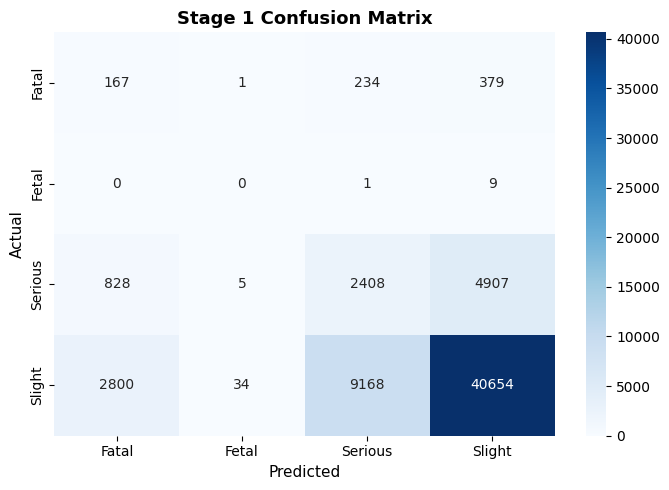

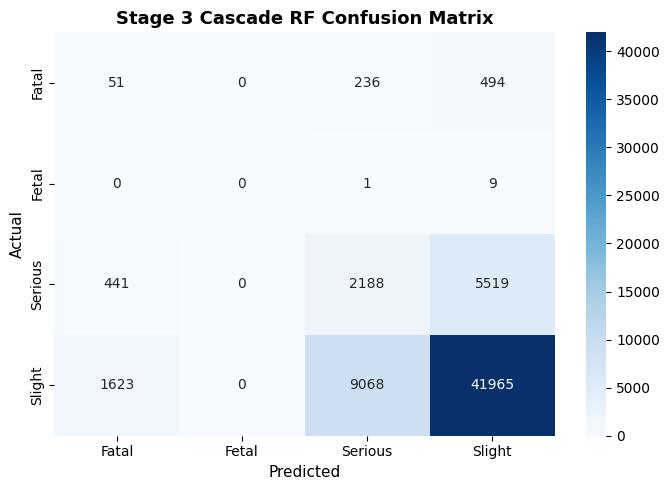

In [19]:
# Confusion Matrix Visualisation
def plot_confusion_matrix(y_true, y_pred, title):
    '''Plot a styled confusion matrix heatmap.'''
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fatal', 'Fetal', 'Serious', 'Slight'],
                yticklabels=['Fatal', 'Fetal', 'Serious', 'Slight'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

plot_confusion_matrix(y_test, stage1_pred_test, 'Stage 1 Confusion Matrix')
plot_confusion_matrix(y_test, stage3_pred_test, 'Stage 3 Cascade RF Confusion Matrix')


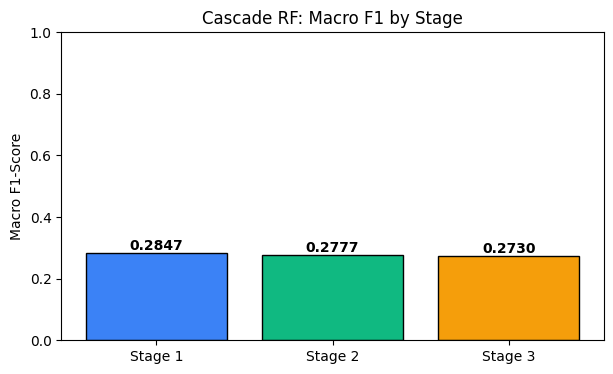

In [20]:
# Stage Comparison Chart
# Compare Macro F1 across all 3 stages
stages = ['Stage 1', 'Stage 2', 'Stage 3']
f1_scores = [
    f1_score(y_test, stage1_pred_test, average='macro'),
    f1_score(y_test, stage2_pred_test, average='macro'),
    f1_score(y_test, stage3_pred_test, average='macro'),
]

plt.figure(figsize=(7, 4))
bars = plt.bar(stages, f1_scores, color=['#3B82F6', '#10B981', '#F59E0B'], edgecolor='black')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', fontweight='bold')
plt.title('Cascade RF: Macro F1 by Stage')
plt.ylabel('Macro F1-Score')
plt.savefig('Cascade_RF_Stage_Comparison.png', dpi=150)
plt.show()

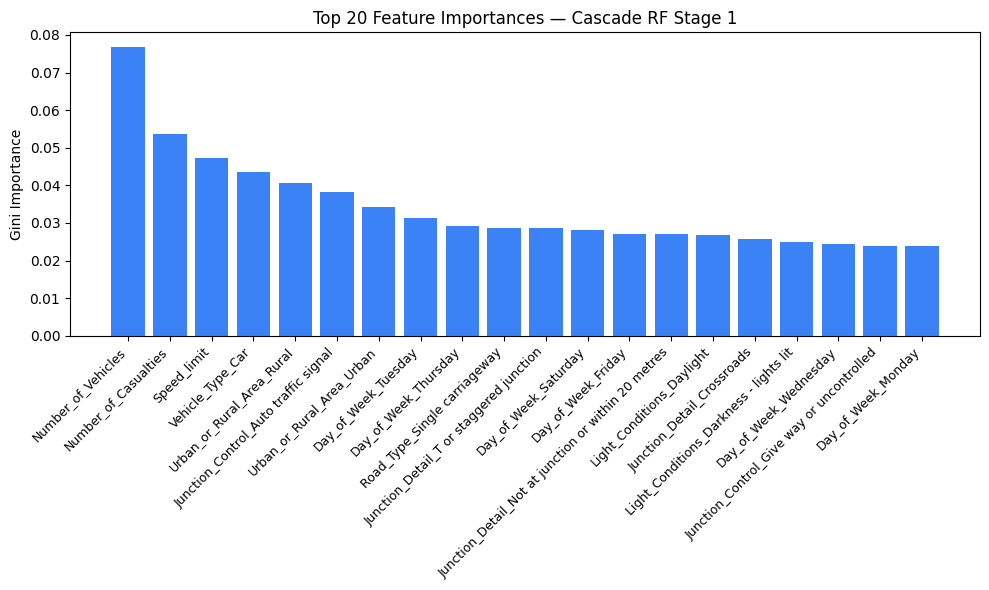

In [21]:
# Feature Importance (Stage 1)
# Plot the top 20 most important features from Stage 1
importances = stage1_rf.feature_importances_

# Get feature names from the preprocessor
cat_feat_names = preproc_tree.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
num_feat_names  = np.array(num_cols)
all_feat_names  = np.concatenate([cat_feat_names, num_feat_names])

# Sort and take top 20
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10, 6))
plt.bar(range(20), importances[indices], color='#3B82F6')
plt.xticks(range(20), all_feat_names[indices], rotation=45, ha='right', fontsize=9)
plt.title('Top 20 Feature Importances — Cascade RF Stage 1')
plt.ylabel('Gini Importance')
plt.tight_layout()
plt.savefig('Feature_Importance.png', dpi=150)
plt.show()

In [22]:
# Save the Final Model
import joblib, os

os.makedirs('artifacts', exist_ok=True)

# Save all stages and the preprocessor in one bundle
cascade_bundle = {
    'stage1': stage1_rf,
    'stage2': stage2_rf,
    'stage3': stage3_rf,
    'preprocessor': preproc_tree,
    'label_encoder': le,
}

joblib.dump(cascade_bundle, 'artifacts/cascade_rf_model.pkl')
print('Model saved to artifacts/cascade_rf_model.pkl')


Model saved to artifacts/cascade_rf_model.pkl
